# Aufgabe 4

## Bestimmung der Stoffmenge n

Um die Stoffmenge zu berechnen nutzen wir die ideale Gasgleichung $pV = nRT$. Wir haben zwar kein ideales Gas, aber ein sehr stark verdünntes Gas als Näherung eines idealen Gases beschrieben werden kann. Also ein hohes Volumen bzw. ein sehr kleines $1/V$:
$$\textrm{lim}_{V\rightarrow \infty}(pV) = nRT$$

Als erstes Stellen wir $pV$ gegen $1/V$ für jede Temperatur in einem Plot da und finden einen Fit dafür. Wenn wir uns den y-Achsenabschnitt dieses Fits anschauen, finden wir den Wert für $\textrm{lim}_{V\rightarrow \infty}(pV)$. Wenn wir diesen Wert noch durch $RT$ teilen, kriegen wir für jede Temperatur die Stoffmenge heraus. Den Mittelwert der 8 Werte nutzen wir dann als bestimmte Stoffmenge n.

<Figure size 4000x3000 with 0 Axes>

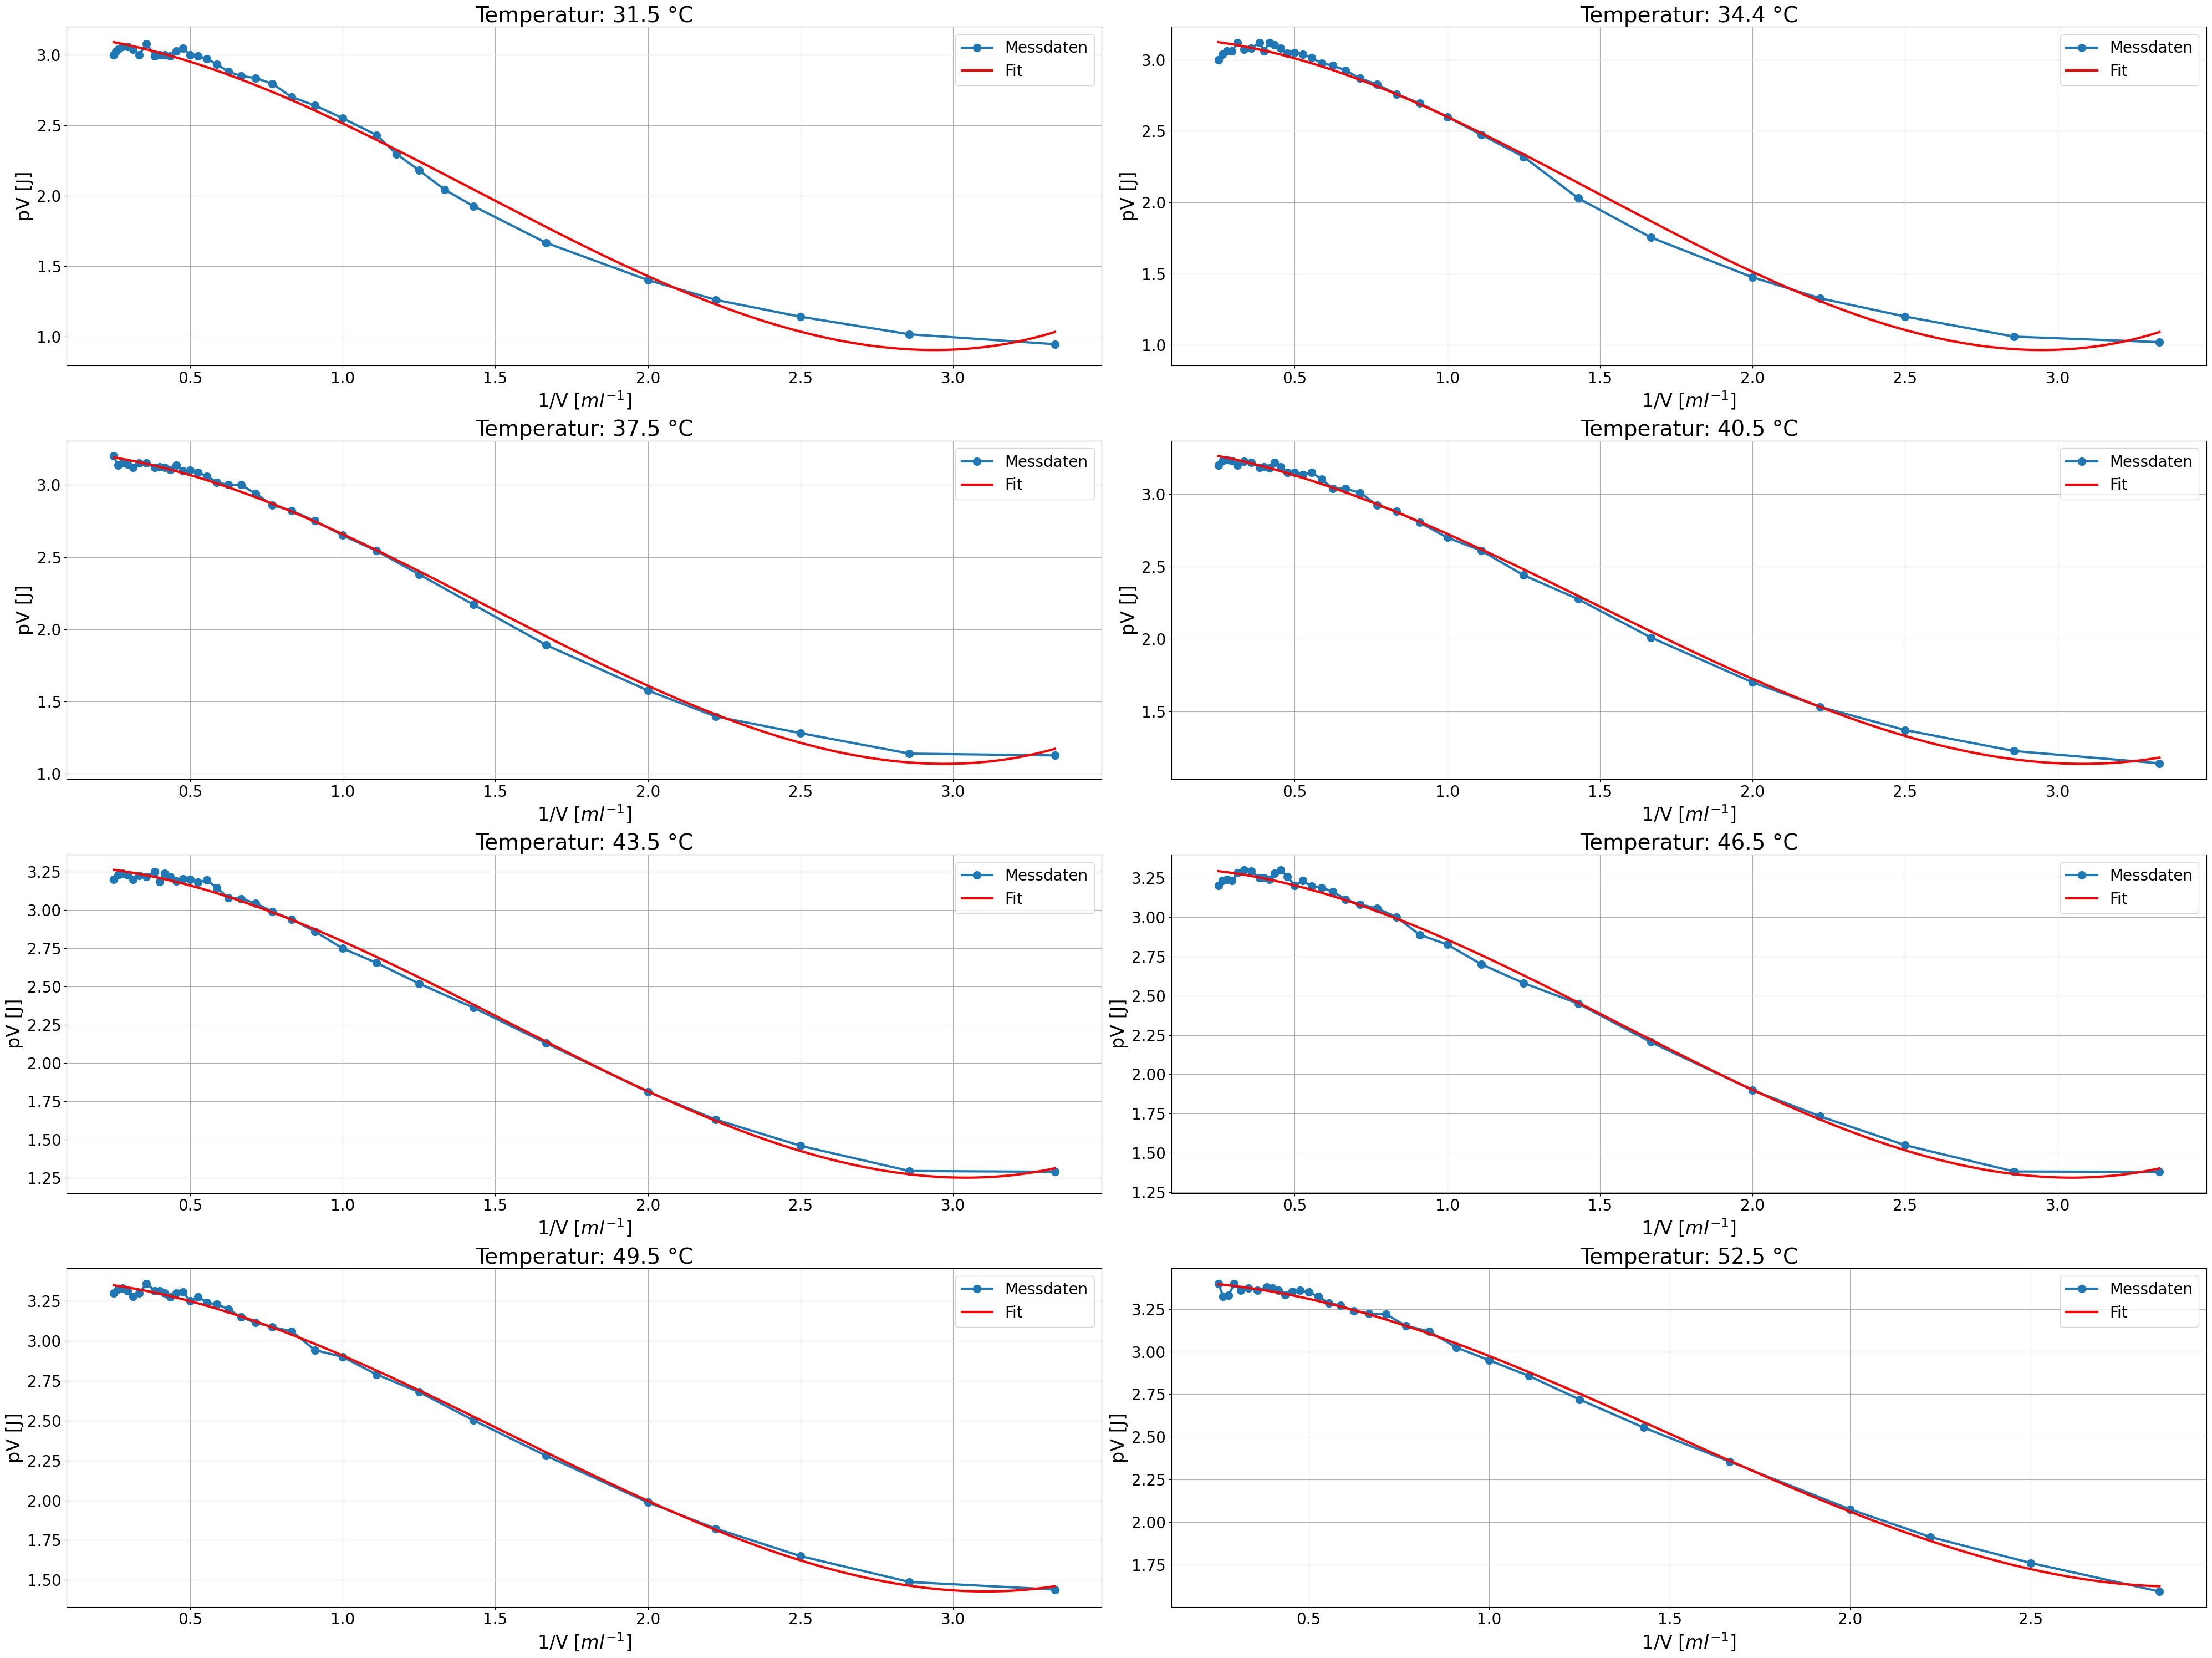

Durchschnittliche Stoffmenge: 0.0012530854984503252 mol
Abweichung: 1.28e-05 mol


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from natsort import natsorted
import os
from scipy.optimize import curve_fit

# Konstanten
R = 8.314462  # J/(mol*K)

# Fit-Funktion: Polynom 3. Ordnung
def poly3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

# Initialisierung der Ergebnislisten
pV = []
v_1 = []
n = []
y_0 = []
temperatur = []
fitts = []
fit_errors = []

# Datenordner
filepath = "Daten"
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

for filename in csv_files:
    # Daten einlesen
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['V[ml]', 'p [10^5 Pa]']

    # Temperatur extrahieren
    temp = float(filename[9:13].replace('_', '.'))

    # Messgrößen berechnen
    df['pV'] = df['V[ml]'] * df['p [10^5 Pa]']/10  # pV in J
    df['1/V'] = 1 / df['V[ml]']

    # Fit mit Polynom 3. Ordnung
    popt, _ = curve_fit(poly3, df['1/V'], df['pV'])
    predicted = poly3(df['1/V'], *popt)
    rmse = np.sqrt(np.mean((df['pV'] - predicted)**2))

    # Parameter extrahieren
    a, b, c, d = popt
    stoffmenge = (d) / (R * (temp + 273.15))  # mol

    # Speicherung
    pV.append(df['pV'])
    v_1.append(df['1/V'])
    n.append(stoffmenge)
    y_0.append(d)
    temperatur.append(temp)
    fitts.append(popt)
    fit_errors.append(rmse)

# Plot
plt.figure(figsize=(40, 30))
fig, axs = plt.subplots(4, 2, figsize=(40, 30))
axs = axs.flatten()

for i in range(len(axs)):
    x_vals = np.linspace(min(v_1[i]), max(v_1[i]), 500)
    axs[i].plot(v_1[i], pV[i], label='Messdaten', linewidth=3, marker='o', markersize=10)
    axs[i].plot(x_vals, poly3(x_vals, *fitts[i]), color="red", label='Fit', linewidth=3)

    axs[i].set_title(f"Temperatur: {temperatur[i]} °C", fontsize=28)
    axs[i].set_xlabel("1/V [$ml^{{-1}}$]", fontsize=24)
    axs[i].set_ylabel("pV [J]", fontsize=24)
    axs[i].tick_params(axis='both', which='major', labelsize=20)
    axs[i].grid(True)
    axs[i].legend(fontsize=20)

plt.tight_layout()
plt.show()

#Ergebnisse in DataFrame speichern
# results = pd.DataFrame({
#     'Temperatur (°C)': temperatur,
#     'Stoffmenge (mol)': n,
#     'Achsenabschnitt (10^5 Pa)': y_0,
#     'Fit-Abweichung RMSE (10^5 Pa·ml)': fit_errors
# })
# print(results)


# Auswertung der Stoffmenge
durchschnittliche_stoffmenge = np.mean(n)
abweichung_stoffmenge = np.std(n)

print(f"Durchschnittliche Stoffmenge: {durchschnittliche_stoffmenge} mol")
print(f"Abweichung: {abweichung_stoffmenge:.2e} mol")


Mithilfe dieser Methode haben wir die durchschnittliche Stoffmenge von $12,53 \cdot 10^{-4} mol$ bestimmt. Hier auch nochmal die Werte für jede einzelne Messung:
| Temperatur (°C) | Stoffmenge (mol) | $\textrm{lim}_{V\rightarrow \infty}(pV)$ (10⁵ Pa) | Mittlere Abweichung (pV) |
|-----------------|------------------|---------------------------|-------------------------|
| 31.5            | 0.001245        | 31.528477                  | 0.592074  |
| 34.4            | 0.001233         | 31.526272                 |0.538834   |
| 37.5            | 0.001253           | 32.363284               |0.313201  |
| 40.5            | 0.001279         | 33.349060                  |0.296100   |
| 43.5            | 0.001251         | 32.936257                |0.298518 |
| 46.5            | 0.001245        | 33.081453                 | 0.365293|
| 49.5            | 0.001262       | 33.850738                |0.251238 |
| 52.5            | 0.001258         | 34.054129                 |0.264685  |


## Fehlerbetrachtung
Bei dieser Aufgabe gibt es zwei große Quellen für Abweichungen. Da wir kein ideales Gas haben, nutzen wir eine Näherung. Der Achsenabschnitt wird mithilfe eines Plots bestimmt, welcher natürlich Abweichungen von den Messdaten hat. Diese Abweichungen sind in der Tabelle mit angegeben. Außerdem wird für den Wert am Ende noch der Mittelwert von allen 8 Messungen berechnet. Dort war die Abweichung $1.28 \cdot 10^{-5} mol$.
